In [ ]:
from ase import atoms
from rdkit.Chem import AllChem
import numpy as np
from ase.calculators.lj import LennardJones
from ase.optimize import BFGS
from ase.visualize import view
from ase import units
from rdkit.Chem import rdMolAlign
from rdkit import Chem
import matplotlib.pyplot as plt
from tblite.ase import TBLite

Molecule setup

In [19]:
input = "CC(C)CC(C)CO"

mol = AllChem.MolFromSmiles(input)
mol = AllChem.AddHs(mol)

2. conformer generation
3. Geometry optimization
4. save optimized structures
- initialize report

In [20]:
# generate + add conformers to the molecule object
# *** FIND WAY TO DETERMINE NUM CONFORMERS BASED ON MOLECULE SIZE/COMPLEXITY
NUM_CONFS = 10
F_MAX = 0.05
ENERGY_THRESHOLD = 5.0 # kcal/mol
RMSD_THRESHOLD = 0.75 # in angstroms, upper threshold for how similar two conformers must be to be considered duplicates
# can be ambiguous/tuned based on molecule size/complexity...maybe implement same algorithm as NUM_CONFS to determine this value based on size + complexity?



params = AllChem.ETKDGv3()
params.randomSeed = 42

AllChem.EmbedMultipleConfs(
    mol,
    numConfs=NUM_CONFS,
    params=params
)


# find proper optimization value




results = []

for conf in mol.GetConformers():
    conf_id = conf.GetId()

    # construct ASE atoms object from conformer
    positions = conf.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    atom = atoms.Atoms(symbols=symbols, positions=positions)

    atom.calc = TBLite(method="GFN2-xTB")
    opt = BFGS(atom)
    opt.run(fmax=F_MAX)

# update rdkit conformer positions with optimized positions from ASE
    optimized_positions = atom.get_positions()
    for idx in range(mol.GetNumAtoms()):
        x, y, z = optimized_positions[idx]
        conf.SetAtomPosition(idx, (float(x), float(y), float(z)))


    # create list of "results" dict, contains each conformer profile
    results.append({
        "id": conf_id,
        "energy": atom.get_potential_energy() * 23.0605, # stores energy in eV --> convert to kcal/mol
        "conformer": conf, # rdkit conformer object
        "atoms": atom.copy() # ASE atoms object for each conformer
    })

results.sort(key=lambda x: x["energy"])
print(f"Number of prefiltered conformers: {len(results)}")

------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -27.13140336085  -2.7458328E+01   1.1370832E-01
      2     -27.17858562910  -4.7182268E-02   5.2584582E-02
      3     -27.18427406780  -5.6884387E-03   1.6010470E-02
      4     -27.18464520794  -3.7114014E-04   7.0346528E-03
      5     -27.18473929942  -9.4091479E-05   1.5046473E-03
      6     -27.18474940189  -1.0102472E-05   8.0131102E-04
      7     -27.18475001824  -6.1634437E-07   1.6463528E-04
      8     -27.18475009943  -8.1194983E-08   6.3024015E-05
      9     -27.18475010626  -6.8310833E-09   1.6437962E-05
------------------------------------------------------------

 total:                                   0.030 sec
      Step     Time          Energy          fmax
BFGS:    0 12:53:29     -739.734729        2.973964
------------------------------------------------------------
 

5. Energy filtering
- remove all optimized conformers 5 kcal/mol above minimum value, not likely to be physically formed

In [21]:
min_energy = results[0]["energy"]
conformer_list_filtered = []

for result in results:
    if result["energy"] - min_energy <= ENERGY_THRESHOLD:
        conformer_list_filtered.append(result)

conformer_list_filtered.sort(key=lambda x: x["energy"])

print(f"Number of filtered conformers: {len(conformer_list_filtered)}")
conformer_list_filtered

Number of filtered conformers: 10


[{'id': 6,
  'energy': np.float64(-17079.46055103278),
  'conformer': <rdkit.Chem.rdchem.Conformer at 0x1d6f2d6eab0>,
  'atoms': Atoms(symbols='C7OH16', pbc=False)},
 {'id': 2,
  'energy': np.float64(-17079.358090119535),
  'conformer': <rdkit.Chem.rdchem.Conformer at 0x1d6f2d35f50>,
  'atoms': Atoms(symbols='C7OH16', pbc=False)},
 {'id': 5,
  'energy': np.float64(-17079.327331010194),
  'conformer': <rdkit.Chem.rdchem.Conformer at 0x1d6f2d63d80>,
  'atoms': Atoms(symbols='C7OH16', pbc=False)},
 {'id': 7,
  'energy': np.float64(-17076.498392745256),
  'conformer': <rdkit.Chem.rdchem.Conformer at 0x1d6f2d7bd80>,
  'atoms': Atoms(symbols='C7OH16', pbc=False)},
 {'id': 4,
  'energy': np.float64(-17076.49535234913),
  'conformer': <rdkit.Chem.rdchem.Conformer at 0x1d6f2d52650>,
  'atoms': Atoms(symbols='C7OH16', pbc=False)},
 {'id': 1,
  'energy': np.float64(-17076.44786162218),
  'conformer': <rdkit.Chem.rdchem.Conformer at 0x1d6f2d260a0>,
  'atoms': Atoms(symbols='C7OH16', pbc=False)},
 

6. RMSD analysis
- pairwise comparisons of each conformer to determine similarity

In [ ]:
# create dictionary with index of conformer: conformer id
index_map = {}
for idx, item in enumerate(conformer_list_filtered):
    index_map[idx] = item["id"]



# rdMolAlign.GetBestRMS() only takes molecule objects and considers conformers by their IDs

# create 0s matrix to store rmsd values
n_conf = len(conformer_list_filtered)

rmsd_matrix = np.zeros((n_conf, n_conf))



# fill in rms values by comparing each conformer to each other conformer (only upper triangle since symmetric)
for i in range(n_conf):
    for j in range(i + 1, n_conf):

        # pulls modified conformers from original mol object using conformer IDs
        id1 = conformer_list_filtered[i]["id"]
        id2 = conformer_list_filtered[j]["id"]

        rmsd_matrix[i, j] = rdMolAlign.GetBestRMS(
            mol, 
            mol, 
            prbId=id1, 
            refId=id2
        )
        rmsd_matrix[j, i] = rmsd_matrix[i, j]



# earlier conformer generation is not deterministic, so there can be different outcomes for filtered conformers
# implement random seed for debugging if needed
print(rmsd_matrix, "\n\n", "Index map: ",index_map)

[[0.         0.93764393 0.94389629 1.52347871 1.70948395 1.59082551
  1.18573718 1.49778052 1.33322987 1.39365277]
 [0.93764393 0.         0.05055844 1.68584717 1.55504577 1.67727317
  1.32334831 1.39854181 1.49635361 1.10010112]
 [0.94389629 0.05055844 0.         1.68328067 1.55290699 1.66342023
  1.34240963 1.40603559 1.51037894 1.09340098]
 [1.52347871 1.68584717 1.68328067 0.         0.73164697 1.3558264
  1.79670383 1.79831173 1.14808417 1.41512627]
 [1.70948395 1.55504577 1.55290699 0.73164697 0.         1.15382192
  1.6786902  1.6574526  1.26570816 1.25061569]
 [1.59082551 1.67727317 1.66342023 1.3558264  1.15382192 0.
  1.20653373 1.57354493 1.2127364  1.16501203]
 [1.18573718 1.32334831 1.34240963 1.79670383 1.6786902  1.20653373
  0.         1.06849882 1.54785124 1.5477994 ]
 [1.49778052 1.39854181 1.40603559 1.79831173 1.6574526  1.57354493
  1.06849882 0.         1.77189915 1.63492217]
 [1.33322987 1.49635361 1.51037894 1.14808417 1.26570816 1.2127364
  1.54785124 1.7718991

7. Heatmap visualization of rmsd_matrix

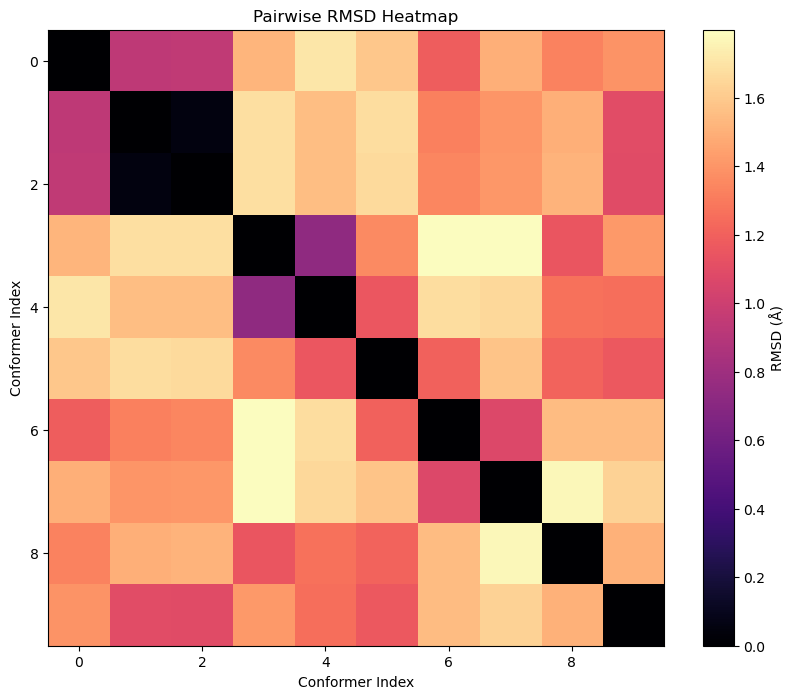

In [23]:
plt.figure(figsize=(10, 8))
plt.imshow(rmsd_matrix, cmap='magma', vmin=0, vmax=np.max(rmsd_matrix))
plt.colorbar(label="RMSD (Å)")

plt.xlabel("Conformer Index")
plt.ylabel("Conformer Index")

plt.title("Pairwise RMSD Heatmap")

plt.show()

In [ ]:

'''
# generate ase Atoms object for more optimal conformer and view
genpositions = results[0]['conformer'].GetPositions()
gensymbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
genatom = atoms.Atoms(symbols=gensymbols, positions=genpositions)
view(genatom)
'''